## Preparación de datos para clasificar vocales

En esta etapa se cargan las columnas de **F1, F2, F3 y duración**, y se toma como variable objetivo `vocal`.

In [6]:
import pandas as pd

# Si ya tienes df cargado desde la celda anterior, no hace falta leerlo otra vez.
# Si no, descomenta la siguiente línea:
df = pd.read_csv("dataset_solo_vocales.csv")

f1_candidates = ["F1", "f1", "F1_Hz", "formant1"]
f2_candidates = ["F2", "f2", "F2_Hz", "formant2"]
f3_candidates = ["F3", "f3", "F3_Hz", "formant3"]
target_candidates = ["vocal", "Vocal", "target_vocal", "label_vocal"]

def find_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(f"No se encontró ninguna de estas columnas: {candidates}. Columnas disponibles: {list(df.columns)}")

f1_col = find_column(df, f1_candidates)
f2_col = find_column(df, f2_candidates)
f3_col = find_column(df, f3_candidates)
target_col = find_column(df, target_candidates)

df_vocal = df[[f1_col, f2_col, f3_col, target_col]].dropna().copy()

X_vocal = df_vocal[[f1_col, f2_col, f3_col]]
y_vocal = df_vocal[target_col]

print("Columnas usadas:")
print(f"  F1:        {f1_col}")
print(f"  F2:        {f2_col}")
print(f"  F3:        {f3_col}")
print(f"  Target:    {target_col}")

print("\nTamaño del dataset limpio:")
print(df_vocal.shape)

print("\nPrimeras filas:")
display(df_vocal.head())

Columnas usadas:
  F1:        F1
  F2:        F2
  F3:        F3
  Target:    vocal

Tamaño del dataset limpio:
(170, 4)

Primeras filas:


,F1,F2,F3,vocal
0,938.5,1633.6,2331.3,AH
1,1004.0,1499.1,2193.2,AA
2,1001.3,1405.5,2604.8,AE
3,886.4,1274.0,2335.5,AO
4,2075.8,2476.1,2864.4,EH


## Separación de datos y entrenamiento del árbol de decisión

Se divide el dataset en entrenamiento y prueba, y luego se entrena un árbol de decisión para clasificar la vocal.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vocal,
    y_vocal,
    test_size=0.2,
    random_state=42,
    stratify=y_vocal
)

tree_vocal = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

tree_vocal.fit(X_train_v, y_train_v)

print("Modelo de vocales entrenado correctamente.")

Modelo de vocales entrenado correctamente.


## Evaluación del modelo

Se evalúa el árbol entrenado sobre el conjunto de prueba.

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_v = tree_vocal.predict(X_test_v)

acc_v = accuracy_score(y_test_v, y_pred_v)
print(f"Accuracy: {acc_v:.4f}\n")

print("Reporte de clasificación:")
print(classification_report(y_test_v, y_pred_v))

print("Matriz de confusión:")
print(confusion_matrix(y_test_v, y_pred_v))

Accuracy: 0.3529

Reporte de clasificación:
              precision    recall  f1-score   support

          AA       0.50      0.33      0.40         3
          AE       0.00      0.00      0.00         3
          AH       0.40      0.67      0.50         3
          AO       0.33      0.25      0.29         4
          EH       0.17      0.25      0.20         4
          ER       0.50      0.33      0.40         3
          IH       0.50      0.25      0.33         4
          IY       0.50      0.67      0.57         3
          UH       0.50      0.25      0.33         4
          UW       0.25      0.67      0.36         3

    accuracy                           0.35        34
   macro avg       0.36      0.37      0.34        34
weighted avg       0.37      0.35      0.33        34

Matriz de confusión:
[[1 0 0 1 0 0 0 0 1 0]
 [0 0 1 0 0 1 0 0 0 1]
 [0 0 2 0 1 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 0]
 [0 0 0 0 1 0 1 1 0 1]
 [0 0 1 0 1 1 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 2]
 [0 0 0 0 0 0 0

c:\Users\aaron\miniconda3\envs\etiquetador_audio\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aaron\miniconda3\envs\etiquetador_audio\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aaron\miniconda3\envs\etiquetador_audio\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

## Visualización del árbol y guardado del modelo

Se muestra la estructura del árbol y se guarda el modelo para usarlo después.

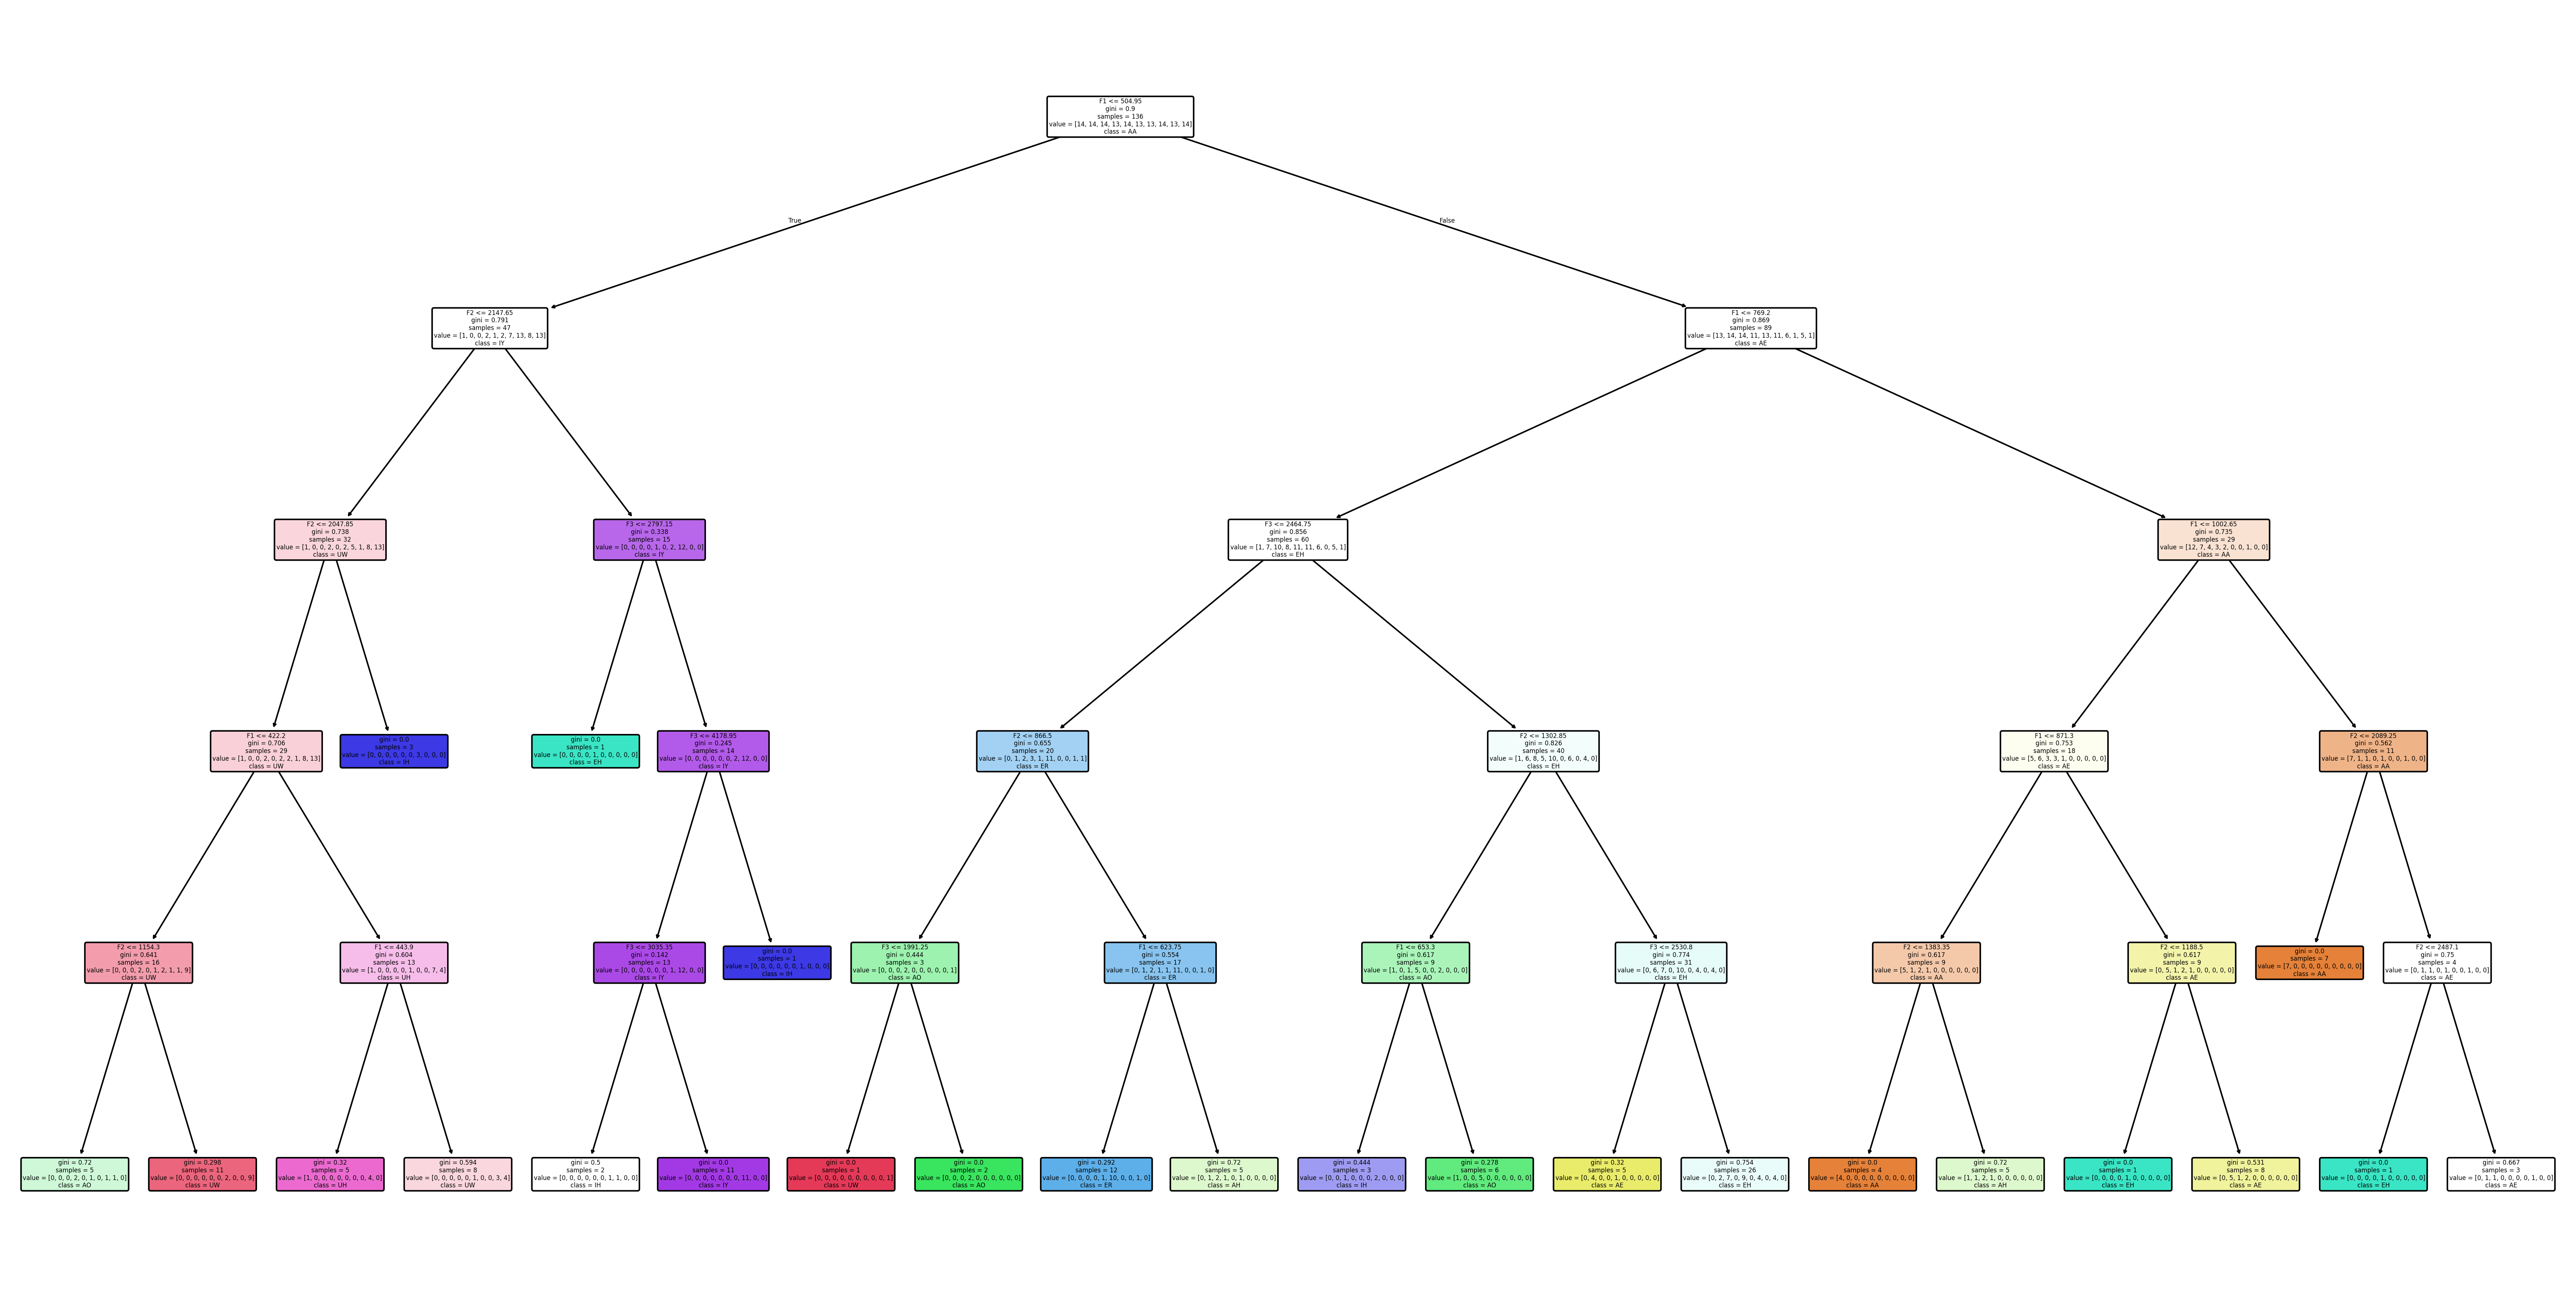

Modelo guardado como decision_tree_vocales.pkl


In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import joblib

plt.figure(figsize=(30, 15), dpi=300)

plot_tree(
    tree_vocal,
    feature_names=X_vocal.columns,
    class_names=[str(c) for c in tree_vocal.classes_],
    filled=True,
    rounded=True,
    fontsize=4
)

plt.show()

joblib.dump(tree_vocal, "decision_tree_vocales.pkl")
print("Modelo guardado como decision_tree_vocales.pkl")